<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 위험도 점수 산출

In [ ]:
import pandas as pd

target_sheets = ['2021', '2022', '2023', '2024', '2025']

dict_accident = pd.read_excel('accident.xlsx', sheet_name=target_sheets)
df_accident = pd.concat(dict_accident.values(), ignore_index=True)

dict_compensation = pd.read_excel('compensation.xlsx', sheet_name=target_sheets)
df_compensation = pd.concat(dict_compensation.values(), ignore_index=True)

In [ ]:
compensation_cols = ['요양급여', '장해급여', '간병급여', '유족급여', '장례비', '위로금', '보전비용']

df_compensation['총보상액'] = df_compensation[compensation_cols].sum(axis=1)

severity_agg = {
    '총보상액': ['sum', 'mean', 'count']
}

severity_df = df_compensation.groupby('사고형태').agg(severity_agg)

severity_df.columns = ['Total_Compensation', 'Average_Compensation', 'Number_of_Cases']

## 학생수 기반 위험도 산출

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

population = {
    '연도': ['2021', '2022', '2023', '2024', '2025'] * 3,
    '학교급': ['초등학교']*5 + ['중학교']*5 + ['고등학교']*5,
    '학생수_천명': [
        2672, 2664, 2604, 2495, 2345,  # 초등학교
        1351, 1348, 1327, 1333, 1370,  # 중학교
        1300, 1262, 1278, 1304, 1299   # 고등학교
    ]
}

df_pop = pd.DataFrame(population)

# 1. 5년(2021~2025) 평균 학생수 산출 (학교급별)
avg_pop = df_pop.groupby('학교급')['학생수_천명'].mean().reset_index()
avg_pop.rename(columns={'학생수_천명': '평균학생수_천명'}, inplace=True)

# 2. 기존 그룹별 집계 시, 빈도(사고 건수)와 심각성(평균 보상액) 산출
group_cols = ['학교급', '사고장소', '사고형태']
risk_df = df_compensation.groupby(group_cols).agg(
    사고건수=('구분', 'count'),
    평균보상액=('총보상액', 'mean')
).reset_index()

# 3. 평균 학생수 결합 및 '빈도율(1,000명당 사고건수)' 계산
risk_df = pd.merge(risk_df, avg_pop, on='학교급', how='left')
risk_df['빈도율'] = risk_df['사고건수'] / risk_df['평균학생수_천명']

# 4. 로그 변환 (이상치 및 편향 보정)
risk_df['log_빈도율'] = np.log1p(risk_df['빈도율'])
risk_df['log_평균보상액'] = np.log1p(risk_df['평균보상액'])

# 5. 1-10점으로 정규화 (Min-Max Scaling)
scaler = MinMaxScaler(feature_range=(0, 10))
risk_df[['빈도_점수', '심도_점수']] = scaler.fit_transform(risk_df[['log_빈도율', 'log_평균보상액']])

# 6. 최종 위험도 점수 산출 (빈도 40%, 심각성 60% 가중치)
w_freq, w_sev = 0.4, 0.6
risk_df['위험도_점수'] = ((risk_df['빈도_점수'] * w_freq) + (risk_df['심도_점수'] * w_sev)).round(2)

In [ ]:
risk_df.head(10)

,학교급,사고장소,사고형태,사고건수,평균보상액,평균학생수_천명,빈도율,log_빈도율,log_평균보상액,빈도_점수,심도_점수,위험도_점수
0,고등학교,가정,그밖의 손상 사고,1,1.680000e+05,1288.6,0.000776,0.000776,12.031725,0.001405,3.860904,2.32
1,고등학교,가정,넘어짐,9,6.226667e+05,1288.6,0.006984,0.006960,13.341768,0.024003,4.848212,2.92
2,고등학교,가정,움직이는 물체와의 부딪힘,1,2.200000e+05,1288.6,0.000776,0.000776,12.301387,0.001405,4.064134,2.44
3,고등학교,가정,이동 중 충격을 가함,1,4.180000e+05,1288.6,0.000776,0.000776,12.943239,0.001405,4.547862,2.73
4,고등학교,강·바다·하천,1미터 미만의 높이에서 떨어짐,3,7.973333e+05,1288.6,0.002328,0.002325,13.589029,0.007068,5.034559,3.02
5,고등학교,강·바다·하천,1미터 이상의 높이에서 떨어짐,1,6.990000e+05,1288.6,0.000776,0.000776,13.457407,0.001405,4.935363,2.96
6,고등학교,강·바다·하천,고정된 물체와의 부딪힘,10,2.509000e+05,1288.6,0.007760,0.007730,12.432814,0.026818,4.163182,2.51
7,고등학교,강·바다·하천,그밖의 손상 사고,6,7.608333e+05,1288.6,0.004656,0.004645,13.542171,0.015545,4.999245,3.01
8,고등학교,강·바다·하천,"긁힘, 찔림",6,7.966667e+04,1288.6,0.004656,0.004645,11.285619,0.015545,3.298604,1.99
9,고등학교,강·바다·하천,넘어짐,12,7.905583e+06,1288.6,0.009312,0.009269,15.883080,0.032441,6.763460,4.07


In [ ]:
top10_risk = risk_df.sort_values(by='위험도_점수', ascending=False).head(10)

top10_risk

,학교급,사고장소,사고형태,사고건수,평균보상액,평균학생수_천명,빈도율,log_빈도율,log_평균보상액,빈도_점수,심도_점수,위험도_점수
1869,중학교,운동장,넘어짐,19436,5.707578e+05,1345.8,14.441968,2.737089,13.254722,10.000000,4.782610,6.87
486,고등학교,운동장,넘어짐,12161,1.168464e+06,1288.6,9.437374,2.345393,13.971201,8.568728,5.322581,6.62
1877,중학교,운동장,움직이는 물체와의 부딪힘,13702,2.509304e+05,1345.8,10.181305,2.414243,12.432935,8.820309,4.163274,6.03
2190,초등학교,교통구역(스쿨존 내)-차도,교통사고,1,5.794510e+08,2556.0,0.000391,0.000391,20.177592,0.000000,10.000000,6.00
1876,중학교,운동장,스포츠 활동 중 충격을 가함,11595,3.772818e+05,1345.8,8.615693,2.263396,12.840750,8.269109,4.470622,5.99
1419,중학교,강당(체육관),움직이는 물체와의 부딪힘,14393,1.903830e+05,1345.8,10.694754,2.459140,12.156798,8.984365,3.955165,5.97
1863,중학교,운동장,고정된 물체와의 부딪힘,11507,3.533198e+05,1345.8,8.550305,2.256573,12.775132,8.244176,4.421169,5.95
1418,중학교,강당(체육관),스포츠 활동 중 충격을 가함,11468,3.481589e+05,1345.8,8.521326,2.253534,12.760417,8.233072,4.410079,5.94
1411,중학교,강당(체육관),넘어짐,10283,4.592508e+05,1345.8,7.640808,2.156496,13.037354,7.878491,4.618792,5.92
31,고등학교,강당(체육관),스포츠 활동 중 충격을 가함,8798,5.963493e+05,1288.6,6.827565,2.057651,13.298583,7.517309,4.815666,5.90


- "중학생/고등학생의 운동장에서 넘어짐" 사고와, "중학생의 운동장에서 움직이는 물체와의 부딪힘" 사고 등이 높은 위험도 점수를 보임

## 위험등급 타깃 지정

In [ ]:
# 1. 6단계 타겟 생성
quantiles = [0, 0.40, 0.70, 0.90, 0.95, 0.99, 1.0]
labels = ['6등급_저위험', '5등급_일반위험', '4등급_중점관리', '3등급_고위험', '2등급_심각위험', '1등급_초고위험']
risk_df['정밀_위험등급'] = pd.qcut(risk_df['위험도_점수'], q=quantiles, labels=labels)

# 2. 4사분면 매트릭스 타겟 생성 (상위 5% 기준)
freq_threshold = risk_df['빈도_점수'].quantile(0.95)
sev_threshold = risk_df['심도_점수'].quantile(0.95)

def get_matrix_target(row):
    if row['빈도_점수'] >= freq_threshold and row['심도_점수'] >= sev_threshold:
        return 'A군_즉각개입 (고빈도+고심도)'
    elif row['빈도_점수'] < freq_threshold and row['심도_점수'] >= sev_threshold:
        return 'B군_인프라강화 (저빈도+고심도)'
    elif row['빈도_점수'] >= freq_threshold and row['심도_점수'] < sev_threshold:
        return 'C군_교육강화 (고빈도+저심도)'
    else:
        return 'D군_모니터링 (저빈도+저심도)'

risk_df['매트릭스_타겟'] = risk_df.apply(get_matrix_target, axis=1)

# 3. 원본 데이터에 매핑
df_model_ready = pd.merge(
    df_compensation,
    risk_df[group_cols + ['위험도_점수', '정밀_위험등급', '매트릭스_타겟']],
    on=group_cols,
    how='left'
)

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!pip install koreanize-matplotlib

import koreanize_matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,489 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direc

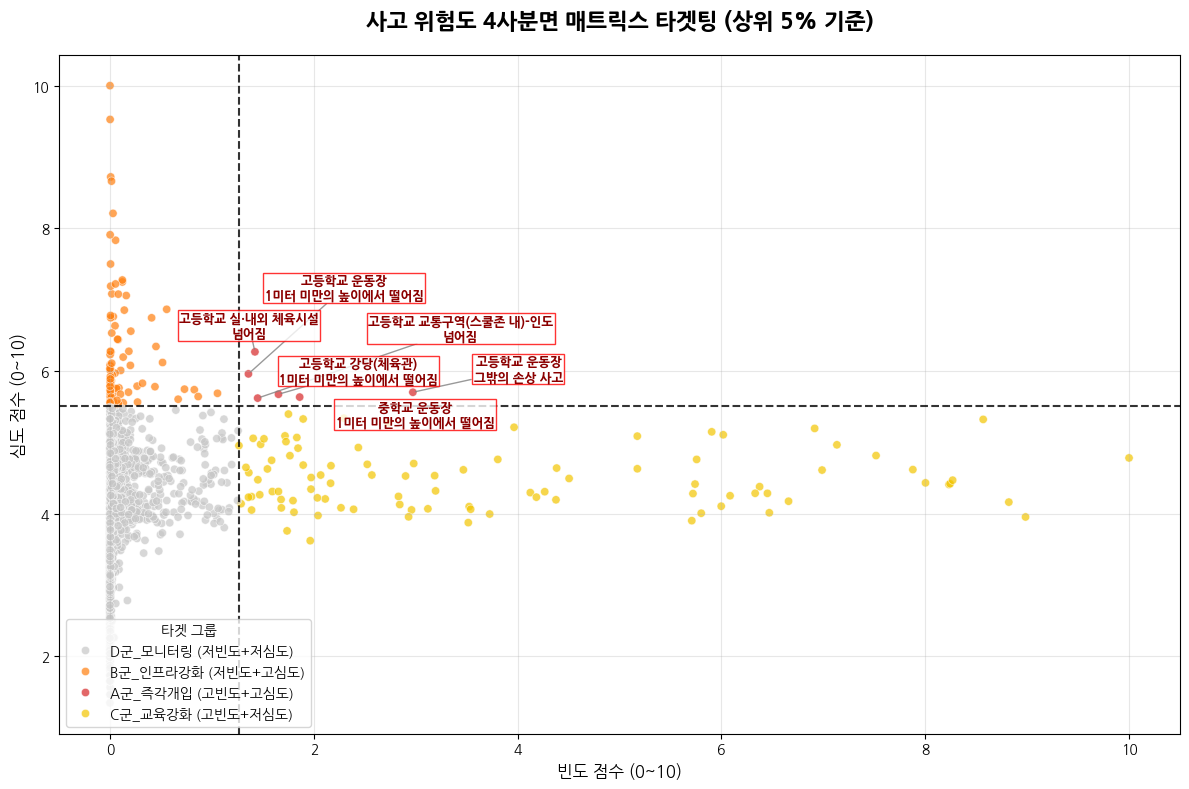

In [ ]:
!pip install adjustText

import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

plt.figure(figsize=(12, 8))

# 4사분면 산점도 그리기
custom_palette = {
    'A군_즉각개입 (고빈도+고심도)': '#d62728',  # Red
    'B군_인프라강화 (저빈도+고심도)': '#ff7f0e',  # Orange
    'C군_교육강화 (고빈도+저심도)': '#f3c500',  # Yellow
    'D군_모니터링 (저빈도+저심도)': '#c7c7c7'   # Grey
}

sns.scatterplot(
    data=risk_df,
    x='빈도_점수',
    y='심도_점수',
    hue='매트릭스_타겟',
    palette=custom_palette,
    alpha=0.7
)

# 기준선 (Threshold) 긋기
# 설정한 상위 5% 기준 (freq_threshold, sev_threshold)
plt.axvline(x=freq_threshold, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=sev_threshold, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

target_a_group = risk_df[risk_df['매트릭스_타겟'] == 'A군_즉각개입 (고빈도+고심도)']

texts = []

for idx, row in target_a_group.iterrows():
    label_text = f"{row['학교급']} {row['사고장소']}\n{row['사고형태']}"

    txt = plt.text(
        x=row['빈도_점수'],
        y=row['심도_점수'],
        s=label_text,
        fontsize=9,
        color='darkred',
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='red', pad=1)
    )
    texts.append(txt)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=1, alpha=0.8))

plt.title('사고 위험도 4사분면 매트릭스 타겟팅 (상위 5% 기준)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('빈도 점수 (0~10)', fontsize=12)
plt.ylabel('심도 점수 (0~10)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='타겟 그룹', loc='lower left')

plt.tight_layout()
plt.show()

- 고등학교: 실내외 체육시설 넘어짐, 운동장 1미터 미만의 높이에서 떨어짐, 교통구역(스쿨존 내) 인도 넘어짐, 강당(체육관) 1미터 미만의 높이에서 떨어짐, 운동장 그밖의 손상 사고
- 중학교: 운동장 1미터 미만의 높이에서 떨어짐
- 위와 같은 사고들은 고빈도+고심도 그룹으로, 즉각개입이 필요하다고 판단됨